# Notebook 02: Activation Patching & Circuit Verification

**Goal:** Verify the causal role of induction heads.

**Outputs:** `experiments/results/baseline_attribution_scores.npz`, `paper/figures/fig1_*`, `paper/figures/fig4_*`

**Runtime:** ~15 minutes on CPU.

In [ ]:
import os
import sys
import numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path

# Define repository information
repo_name = "Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning"
repo_url = "https://github.com/Mattral/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning"
repo_path = f"/content/{repo_name}"

# Clone the repository if it doesn't exist
if not os.path.exists(repo_path):
    print(f"Cloning {repo_url} to {repo_path}...")
    !git clone {repo_url} {repo_path}

# Change current working directory to the repository root
if os.getcwd() != repo_path:
    print(f"Changing current directory to {repo_path}")
    os.chdir(repo_path)

# Add the current directory (repo root) to sys.path
if '.' not in sys.path:
    sys.path.insert(0, '.')

# Install project dependencies
print(f"Installing dependencies from {repo_path}/requirements.txt...")
!pip install -r requirements.txt

### ⚠️ Restart Runtime Required
Please go to **Runtime -> Restart session** now. After the session restarts, run the cell below to load the modules and continue.

In [1]:
# After restarting the runtime, re-run this cell to continue.
import numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

repo_name = "Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning"
repo_path = f"/content/{repo_name}"

if os.getcwd() != repo_path:
    os.chdir(repo_path)

if '.' not in sys.path:
    sys.path.insert(0, '.')

from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.patching import compute_circuit_attribution, get_circuit_heads
from src.viz.circuit_diagram import plot_circuit_diagram, plot_attribution_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


In [2]:
import sys; sys.path.insert(0, '..')
import numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path
from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.patching import compute_circuit_attribution, get_circuit_heads
from src.viz.circuit_diagram import plot_circuit_diagram, plot_attribution_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
model_config = ModelConfig(); eval_config = EvalConfig()
model = load_pretrained_model(model_config, device=device)

config.json: 0.00B [00:00, ?B/s]

./model_final.pth:   0%|          | 0.00/210M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cpu


In [4]:
attribution_scores = compute_circuit_attribution(
    model=model, seq_len=20, batch_size=32, seed=eval_config.seed, device=device,
)
circuit_heads = get_circuit_heads(attribution_scores, threshold=eval_config.induction_circuit_threshold)
print('Circuit heads:', circuit_heads)
print('Max attribution:', attribution_scores.max().item())

Circuit heads: [(1, 6)]
Max attribution: 0.9559518098831177


In [5]:
results_dir = Path('../experiments/results'); results_dir.mkdir(parents=True, exist_ok=True)
np.savez(results_dir / 'baseline_attribution_scores.npz',
         attribution_scores=attribution_scores.cpu().numpy(),
         circuit_heads=np.array(circuit_heads))
print('Saved.')

Saved.


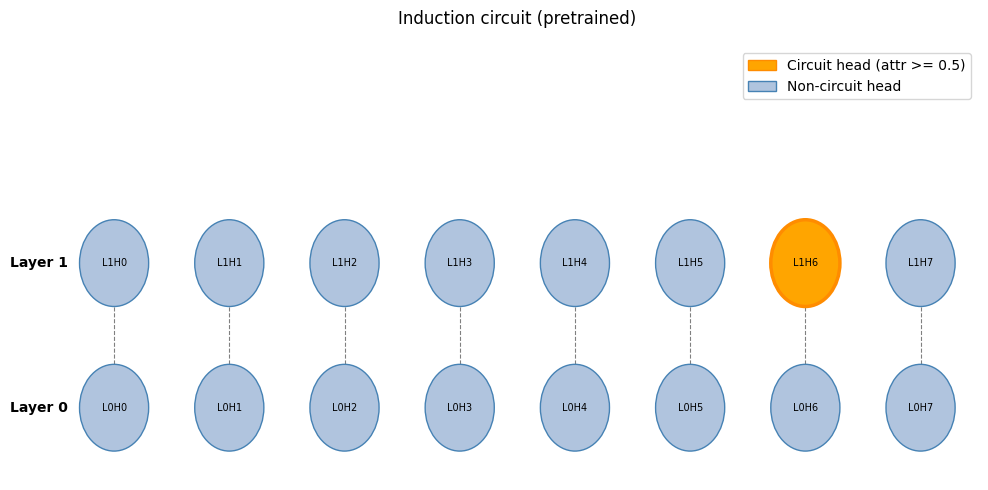

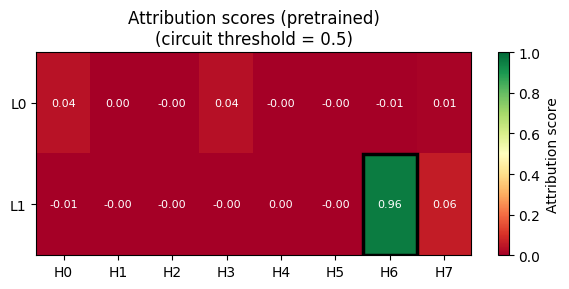

In [6]:
figures_dir = Path('../paper/figures'); figures_dir.mkdir(parents=True, exist_ok=True)
fig1 = plot_circuit_diagram(circuit_heads=circuit_heads, n_layers=model.cfg.n_layers, n_heads=model.cfg.n_heads,
    title='Induction circuit (pretrained)', save_path=figures_dir / 'fig1_circuit_diagram')
plt.show()
fig4 = plot_attribution_heatmap(attribution_scores.cpu().numpy(), threshold=eval_config.induction_circuit_threshold,
    title='Attribution scores (pretrained)', save_path=figures_dir / 'fig4_attribution_baseline')
plt.show()

In [11]:
from google.colab import files
import os
from pathlib import Path

print("Downloading individual output files...")

# Ensure we are in the correct directory if the notebook state changed
repo_name = "Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning"
repo_path = f"/content/{repo_name}"

if os.getcwd() != repo_path:
    print(f"Changing current directory to {repo_path}")
    os.chdir(repo_path)

# Define the files to download
files_to_download = [
    '../experiments/results/baseline_attribution_scores.npz',
    '../paper/figures/fig1_circuit_diagram.png',
    '../paper/figures/fig1_circuit_diagram.pdf',
    '../paper/figures/fig4_attribution_baseline.pdf',
    '../paper/figures/fig4_attribution_baseline.png'
]

# Download each file individually
for file_path in files_to_download:
    if Path(file_path).exists():
        print(f"Downloading {file_path}...")
        files.download(file_path)
    else:
        print(f"Warning: File not found at {file_path}. Skipping download.")

print("All requested files have been processed.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All requested files have been processed.
